In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score,classification_report, confusion_matrix)
import joblib

In [2]:
# Paths
DATA_DIR   = Path("../data/processed/tabular_data")
MODELS_DIR = Path("../data/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Load splits
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

# Separate features and labels
LABEL_COLS = ["exercise_name_encoded", "exercise_correctness_encoded"]
feature_cols = [c for c in train_df.columns if c not in LABEL_COLS]

X_train, X_val, X_test = train_df[feature_cols], val_df[feature_cols], test_df[feature_cols]

y_ex_train,  y_cor_train  = train_df["exercise_name_encoded"],  train_df["exercise_correctness_encoded"]
y_ex_val,    y_cor_val    = val_df["exercise_name_encoded"],    val_df["exercise_correctness_encoded"]
y_ex_test,   y_cor_test   = test_df["exercise_name_encoded"],   test_df["exercise_correctness_encoded"]

print("✅ Splits loaded.")
print(f"   Train : {X_train.shape}")
print(f"   Val   : {X_val.shape}")
print(f"   Test  : {X_test.shape}")

✅ Splits loaded.
   Train : (13480, 26)
   Val   : (3724, 26)
   Test  : (2145, 26)


In [3]:
EXERCISE_NAMES    = {0: "pullup", 1: "pushup", 2: "russian_twist", 3: "squat"}
CORRECTNESS_NAMES = {0: "incorrect", 1: "correct"}

def evaluate_model(model, X, y, label_map, model_name, task_name, split_name):
    """
    Evaluates a trained model on a given split.
    Prints classification report and plots confusion matrix.
    """
    label_names = [label_map[k] for k in sorted(label_map.keys())]
    y_pred = model.predict(X)
    acc    = accuracy_score(y, y_pred)
    f1     = f1_score(y, y_pred, average="weighted")

    print(f"\n{'='*50}")
    print(f"  {model_name} — {task_name} [{split_name}]")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f} (weighted)")
    print(f"\n{classification_report(y, y_pred, target_names=label_names)}")

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — {task_name} [{split_name}]")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(MODELS_DIR / f"images/cm_{model_name.lower().replace(' ', '_')}_{task_name.lower().replace(' ', '_')}_{split_name.lower()}.png", dpi=150)
    plt.show()

    return {"model": model_name, "task": task_name, "split": split_name, "accuracy": acc, "f1": f1}

print("✅ Evaluation helper function defined.")

✅ Evaluation helper function defined.


✅ Random Forest (Exercise) trained.

  Random Forest — Exercise Classification [Validation]
  Accuracy : 0.8330
  F1 Score : 0.8329 (weighted)

               precision    recall  f1-score   support

       pullup       0.73      0.82      0.77       923
       pushup       0.66      0.70      0.68       732
russian_twist       0.97      1.00      0.98      1313
        squat       0.92      0.70      0.80       756

     accuracy                           0.83      3724
    macro avg       0.82      0.80      0.81      3724
 weighted avg       0.84      0.83      0.83      3724



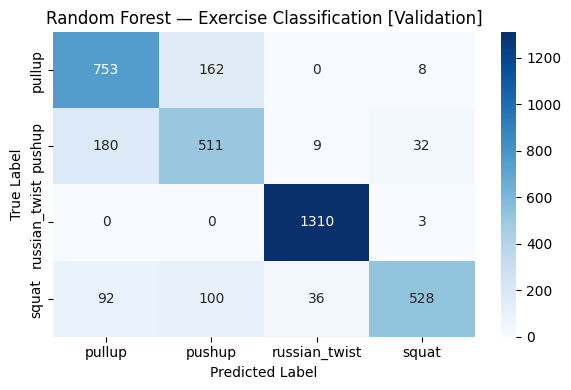


💾 Model saved → ..\data\models\rf_exercise.pkl


In [4]:
rf_exercise = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_exercise.fit(X_train, y_ex_train)
print("✅ Random Forest (Exercise) trained.")

# Evaluate on validation set only
results_rf_ex = evaluate_model(
    model      = rf_exercise,
    X          = X_val,
    y          = y_ex_val,
    label_map  = EXERCISE_NAMES,
    model_name = "Random Forest",
    task_name  = "Exercise Classification",
    split_name = "Validation"
)

# Save model
joblib.dump(rf_exercise, MODELS_DIR / "rf_exercise.pkl")
print(f"\n💾 Model saved → {MODELS_DIR / 'rf_exercise.pkl'}")

✅ Random Forest (Correctness) trained.

  Random Forest — Correctness Classification [Validation]
  Accuracy : 0.5357
  F1 Score : 0.5264 (weighted)

              precision    recall  f1-score   support

   incorrect       0.83      0.37      0.51      2448
     correct       0.41      0.86      0.56      1276

    accuracy                           0.54      3724
   macro avg       0.62      0.61      0.53      3724
weighted avg       0.69      0.54      0.53      3724



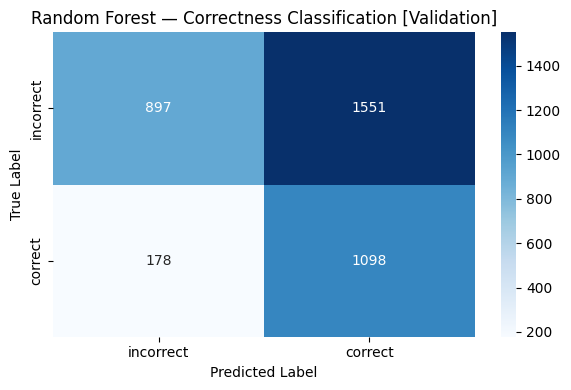


💾 Model saved → ..\data\models\rf_correctness.pkl


In [5]:
rf_correctness = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",   # handles correct/incorrect imbalance
    random_state=42,
    n_jobs=-1
)

rf_correctness.fit(X_train, y_cor_train)
print("✅ Random Forest (Correctness) trained.")

# Evaluate on validation set only
results_rf_cor = evaluate_model(
    model      = rf_correctness,
    X          = X_val,
    y          = y_cor_val,
    label_map  = CORRECTNESS_NAMES,
    model_name = "Random Forest",
    task_name  = "Correctness Classification",
    split_name = "Validation"
)

# Save model
joblib.dump(rf_correctness, MODELS_DIR / "rf_correctness.pkl")
print(f"\n💾 Model saved → {MODELS_DIR / 'rf_correctness.pkl'}")

✅ SVM (Exercise) trained.

  SVM — Exercise Classification [Validation]
  Accuracy : 0.8818
  F1 Score : 0.8802 (weighted)

               precision    recall  f1-score   support

       pullup       0.83      0.88      0.86       923
       pushup       0.78      0.88      0.83       732
russian_twist       0.97      0.99      0.98      1313
        squat       0.91      0.69      0.79       756

     accuracy                           0.88      3724
    macro avg       0.87      0.86      0.86      3724
 weighted avg       0.89      0.88      0.88      3724



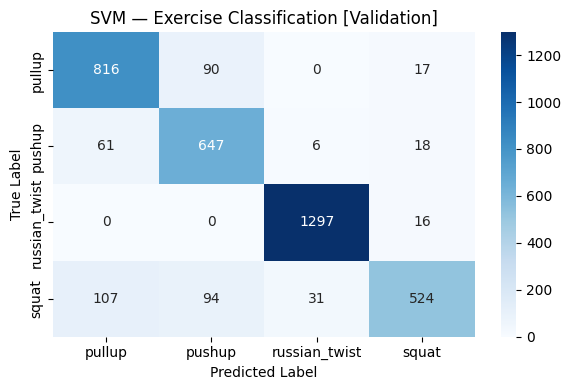


💾 Model saved → ..\data\models\svm_exercise.pkl


In [6]:
svm_exercise = SVC(
    kernel="rbf",        # handles non-linear boundaries between exercise types
    C=10,                # regularization — higher C = less margin tolerance
    gamma="scale",       # automatically scales with number of features
    class_weight="balanced",
    random_state=42
)

svm_exercise.fit(X_train, y_ex_train)
print("✅ SVM (Exercise) trained.")

# Evaluate on validation set only
results_svm_ex = evaluate_model(
    model      = svm_exercise,
    X          = X_val,
    y          = y_ex_val,
    label_map  = EXERCISE_NAMES,
    model_name = "SVM",
    task_name  = "Exercise Classification",
    split_name = "Validation"
)

# Save model
joblib.dump(svm_exercise, MODELS_DIR / "svm_exercise.pkl")
print(f"\n💾 Model saved → {MODELS_DIR / 'svm_exercise.pkl'}")

✅ SVM (Correctness) trained.

  SVM — Correctness Classification [Validation]
  Accuracy : 0.5502
  F1 Score : 0.5462 (weighted)

              precision    recall  f1-score   support

   incorrect       0.83      0.40      0.54      2448
     correct       0.42      0.84      0.56      1276

    accuracy                           0.55      3724
   macro avg       0.62      0.62      0.55      3724
weighted avg       0.69      0.55      0.55      3724



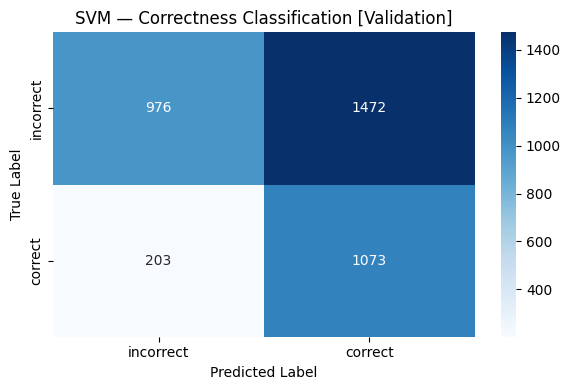


💾 Model saved → ..\data\models\svm_correctness.pkl


In [7]:
svm_correctness = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

svm_correctness.fit(X_train, y_cor_train)
print("✅ SVM (Correctness) trained.")

# Evaluate on validation set only
results_svm_cor = evaluate_model(
    model      = svm_correctness,
    X          = X_val,
    y          = y_cor_val,
    label_map  = CORRECTNESS_NAMES,
    model_name = "SVM",
    task_name  = "Correctness Classification",
    split_name = "Validation"
)

# Save model
joblib.dump(svm_correctness, MODELS_DIR / "svm_correctness.pkl")
print(f"\n💾 Model saved → {MODELS_DIR / 'svm_correctness.pkl'}")

In [8]:
'''from sklearn.model_selection import learning_curve

print("📈 Generating learning curves and RF training progression...\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Training Analysis", fontsize=14)

# ── Learning Curve helper ─────────────────────────────────────
def plot_learning_curve(model, X, y, ax, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring="f1_weighted",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", color="royalblue",  label="Train F1")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="royalblue")
    ax.plot(train_sizes, val_mean,   "o-", color="darkorange", label="Validation F1")
    ax.fill_between(train_sizes, val_mean - val_std,   val_mean + val_std,   alpha=0.15, color="darkorange")
    ax.set_title(title)
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Weighted F1 Score")
    ax.legend(loc="lower right")
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)

plot_learning_curve(rf_exercise,    X_train, y_ex_train,  axes[0][0], "RF — Exercise Classification")
plot_learning_curve(rf_correctness, X_train, y_cor_train, axes[0][1], "RF — Correctness Classification")
plot_learning_curve(svm_exercise,   X_train, y_ex_train,  axes[1][0], "SVM — Exercise Classification")
plot_learning_curve(svm_correctness,X_train, y_cor_train, axes[1][1], "SVM — Correctness Classification")

plt.tight_layout()
plt.savefig(MODELS_DIR / "learning_curves.png", dpi=150)
plt.show()

# ── RF: OOB Error vs. n_estimators (analogous to "loss per epoch") ───
print("\n📉 RF OOB Error vs. Number of Trees (analogous to loss curve)...\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Random Forest: OOB Error vs. n_estimators", fontsize=13)

for ax, (label, X_tr, y_tr) in zip(axes, [
    ("Exercise Classification",    X_train, y_ex_train),
    ("Correctness Classification", X_train, y_cor_train),
]):
    oob_errors = []
    n_estimators_range = range(10, 210, 10)
    for n in n_estimators_range:
        rf = RandomForestClassifier(
            n_estimators=n,
            oob_score=True,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_tr, y_tr)
        oob_errors.append(1 - rf.oob_score_)

    ax.plot(n_estimators_range, oob_errors, "o-", color="steelblue")
    ax.set_title(label)
    ax.set_xlabel("Number of Trees (n_estimators)")
    ax.set_ylabel("OOB Error Rate")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(MODELS_DIR / "rf_oob_error.png", dpi=150)
plt.show()

print("✅ All training analysis plots saved.")'''

'from sklearn.model_selection import learning_curve\n\nprint("📈 Generating learning curves and RF training progression...\n")\n\nfig, axes = plt.subplots(2, 2, figsize=(14, 10))\nfig.suptitle("Model Training Analysis", fontsize=14)\n\n# ── Learning Curve helper ─────────────────────────────────────\ndef plot_learning_curve(model, X, y, ax, title):\n    train_sizes, train_scores, val_scores = learning_curve(\n        model, X, y,\n        cv=5,\n        scoring="f1_weighted",\n        train_sizes=np.linspace(0.1, 1.0, 10),\n        n_jobs=-1\n    )\n    train_mean = train_scores.mean(axis=1)\n    train_std  = train_scores.std(axis=1)\n    val_mean   = val_scores.mean(axis=1)\n    val_std    = val_scores.std(axis=1)\n\n    ax.plot(train_sizes, train_mean, "o-", color="royalblue",  label="Train F1")\n    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="royalblue")\n    ax.plot(train_sizes, val_mean,   "o-", color="darkorange", label="Validati

🔬 Running final evaluation on TEST SET for all models...


  Random Forest — Exercise Classification [Test]
  Accuracy : 0.9548
  F1 Score : 0.9547 (weighted)

               precision    recall  f1-score   support

       pullup       0.84      0.99      0.91       488
       pushup       0.99      0.83      0.90       547
russian_twist       1.00      1.00      1.00       618
        squat       1.00      1.00      1.00       492

     accuracy                           0.95      2145
    macro avg       0.96      0.96      0.95      2145
 weighted avg       0.96      0.95      0.95      2145



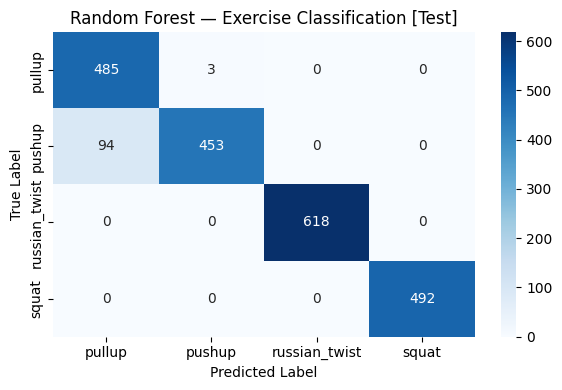


  Random Forest — Correctness Classification [Test]
  Accuracy : 0.6629
  F1 Score : 0.6845 (weighted)

              precision    recall  f1-score   support

   incorrect       0.41      0.75      0.53       546
     correct       0.88      0.63      0.74      1599

    accuracy                           0.66      2145
   macro avg       0.65      0.69      0.63      2145
weighted avg       0.76      0.66      0.68      2145



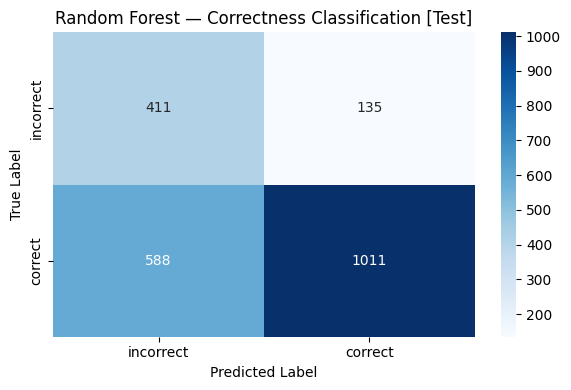


  SVM — Exercise Classification [Test]
  Accuracy : 0.9944
  F1 Score : 0.9944 (weighted)

               precision    recall  f1-score   support

       pullup       0.99      0.99      0.99       488
       pushup       0.99      0.99      0.99       547
russian_twist       1.00      1.00      1.00       618
        squat       1.00      1.00      1.00       492

     accuracy                           0.99      2145
    macro avg       0.99      0.99      0.99      2145
 weighted avg       0.99      0.99      0.99      2145



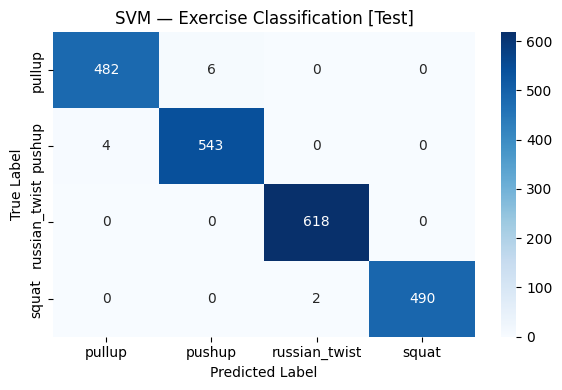


  SVM — Correctness Classification [Test]
  Accuracy : 0.6177
  F1 Score : 0.6418 (weighted)

              precision    recall  f1-score   support

   incorrect       0.38      0.77      0.51       546
     correct       0.88      0.57      0.69      1599

    accuracy                           0.62      2145
   macro avg       0.63      0.67      0.60      2145
weighted avg       0.75      0.62      0.64      2145



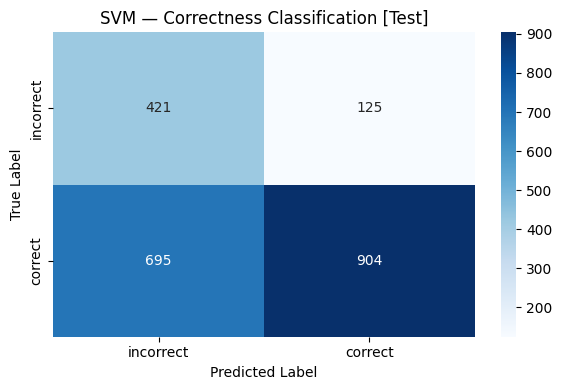


        FINAL MODEL COMPARISON — TEST SET


,model,task,accuracy,f1
0,Random Forest,Exercise Classification,0.9548,0.9547
1,Random Forest,Correctness Classification,0.6629,0.6845
2,SVM,Exercise Classification,0.9944,0.9944
3,SVM,Correctness Classification,0.6177,0.6418



💾 Comparison table saved → ..\data\models\images\model_comparison.csv


In [9]:
print("🔬 Running final evaluation on TEST SET for all models...\n")

# Evaluate all 4 models on test set
test_results = []

test_results.append(evaluate_model(
    model      = rf_exercise,
    X          = X_test,
    y          = y_ex_test,
    label_map  = EXERCISE_NAMES,
    model_name = "Random Forest",
    task_name  = "Exercise Classification",
    split_name = "Test"
))

test_results.append(evaluate_model(
    model      = rf_correctness,
    X          = X_test,
    y          = y_cor_test,
    label_map  = CORRECTNESS_NAMES,
    model_name = "Random Forest",
    task_name  = "Correctness Classification",
    split_name = "Test"
))

test_results.append(evaluate_model(
    model      = svm_exercise,
    X          = X_test,
    y          = y_ex_test,
    label_map  = EXERCISE_NAMES,
    model_name = "SVM",
    task_name  = "Exercise Classification",
    split_name = "Test"
))

test_results.append(evaluate_model(
    model      = svm_correctness,
    X          = X_test,
    y          = y_cor_test,
    label_map  = CORRECTNESS_NAMES,
    model_name = "SVM",
    task_name  = "Correctness Classification",
    split_name = "Test"
))

# Build comparison table
results_df = pd.DataFrame(test_results)[["model", "task", "accuracy", "f1"]]
results_df["accuracy"] = results_df["accuracy"].round(4)
results_df["f1"]       = results_df["f1"].round(4)

print("\n" + "="*60)
print("        FINAL MODEL COMPARISON — TEST SET")
print("="*60)
display(results_df)

# Save comparison table
results_df.to_csv(MODELS_DIR / "model_comparison.csv", index=False)
print(f"\n💾 Comparison table saved → {MODELS_DIR / 'images/model_comparison.csv'}")

In [11]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from scipy.stats import uniform, loguniform
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Hyperparameter search spaces ──────────────────────────────
rf_param_dist = {
    "n_estimators":    [100, 200, 300, 500],
    "max_depth":       [None, 10, 20, 30],
    "min_samples_leaf":[1, 2, 5],
    "max_features":    ["sqrt", "log2", 0.5],
    "class_weight":    ["balanced"],
}

svm_param_dist = {
    "C":           loguniform(0.1, 500),   # log-uniform from 0.1 to ~500
    "gamma":       ["scale", "auto", 0.001, 0.01, 0.1],
    "kernel":      ["rbf"],
    "class_weight":["balanced"],
}

# ── Helper ────────────────────────────────────────────────────
def run_search(estimator, param_dist, X, y, task_name, n_iter=30):
    print(f"\n🔍 Tuning {estimator.__class__.__name__} — {task_name}")
    search = RandomizedSearchCV(
        estimator,
        param_dist,
        n_iter=n_iter,
        scoring="f1_weighted",
        cv=CV,
        n_jobs=2,
        random_state=RANDOM_STATE,
        verbose=1,
    )
    search.fit(X, y)
    print(f"  ✅ Best CV F1  : {search.best_score_:.4f}")
    print(f"  📋 Best params : {search.best_params_}")
    return search.best_estimator_, search.best_params_, search.best_score_

# ── Tune RF correctness (most impactful) ──────────────────────
rf_cor_tuned, rf_cor_params, rf_cor_cv = run_search(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=2),
    rf_param_dist,
    X_train, y_cor_train,
    task_name="Correctness Classification",
    n_iter=40,
)

# ── Tune SVM correctness (most room to improve) ───────────────
svm_cor_tuned, svm_cor_params, svm_cor_cv = run_search(
    SVC(random_state=RANDOM_STATE),
    svm_param_dist,
    X_train, y_cor_train,
    task_name="Correctness Classification",
    n_iter=20,
)

# ── Also tune exercise classifiers (for completeness) ─────────
rf_ex_tuned, rf_ex_params, rf_ex_cv = run_search(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=2),
    rf_param_dist,
    X_train, y_ex_train,
    task_name="Exercise Classification",
    n_iter=40,
)

svm_ex_tuned, svm_ex_params, svm_ex_cv = run_search(
    SVC(random_state=RANDOM_STATE),
    svm_param_dist,
    X_train, y_ex_train,
    task_name="Exercise Classification",
    n_iter=20,
)


🔍 Tuning RandomForestClassifier — Correctness Classification
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  ✅ Best CV F1  : 0.9728
  📋 Best params : {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': 'balanced'}

🔍 Tuning SVC — Correctness Classification
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  ✅ Best CV F1  : 0.9399
  📋 Best params : {'C': np.float64(151.66793369550652), 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'rbf'}

🔍 Tuning RandomForestClassifier — Exercise Classification
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  ✅ Best CV F1  : 0.9993
  📋 Best params : {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}

🔍 Tuning SVC — Exercise Classification
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  ✅ Best CV F1  : 0.9961
  📋 Best params : {'C': np.float64(323.51851456174325), 'class_weight


  TUNED MODEL RESULTS — TEST SET

  RF (tuned) — Exercise Classification [Test]
  Accuracy : 0.9538
  F1 Score : 0.9537 (weighted)

               precision    recall  f1-score   support

       pullup       0.84      0.99      0.91       488
       pushup       0.99      0.83      0.90       547
russian_twist       1.00      1.00      1.00       618
        squat       1.00      1.00      1.00       492

     accuracy                           0.95      2145
    macro avg       0.96      0.95      0.95      2145
 weighted avg       0.96      0.95      0.95      2145



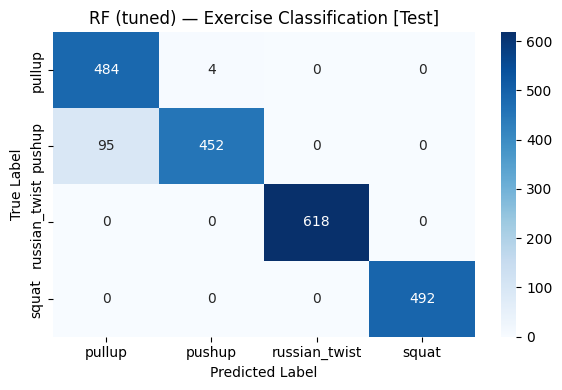


  RF (tuned) — Correctness Classification [Test]
  Accuracy : 0.6625
  F1 Score : 0.6842 (weighted)

              precision    recall  f1-score   support

   incorrect       0.41      0.77      0.54       546
     correct       0.89      0.63      0.73      1599

    accuracy                           0.66      2145
   macro avg       0.65      0.70      0.64      2145
weighted avg       0.77      0.66      0.68      2145



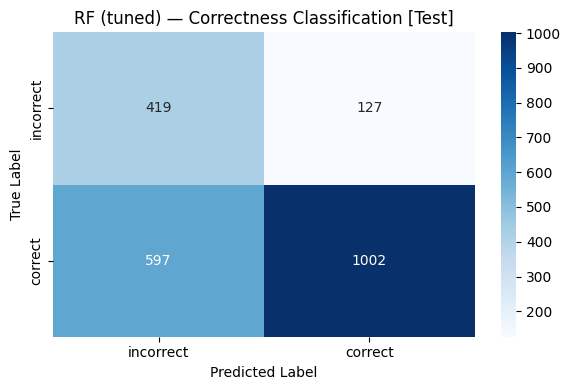


  SVM (tuned) — Exercise Classification [Test]
  Accuracy : 0.9930
  F1 Score : 0.9930 (weighted)

               precision    recall  f1-score   support

       pullup       0.99      0.99      0.99       488
       pushup       0.99      0.99      0.99       547
russian_twist       1.00      1.00      1.00       618
        squat       0.99      1.00      1.00       492

     accuracy                           0.99      2145
    macro avg       0.99      0.99      0.99      2145
 weighted avg       0.99      0.99      0.99      2145



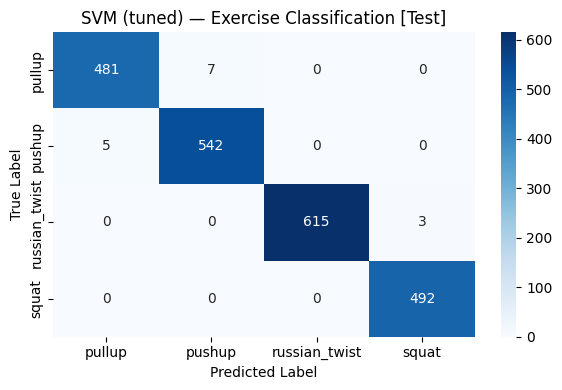


  SVM (tuned) — Correctness Classification [Test]
  Accuracy : 0.5501
  F1 Score : 0.5770 (weighted)

              precision    recall  f1-score   support

   incorrect       0.32      0.70      0.44       546
     correct       0.83      0.50      0.62      1599

    accuracy                           0.55      2145
   macro avg       0.58      0.60      0.53      2145
weighted avg       0.70      0.55      0.58      2145



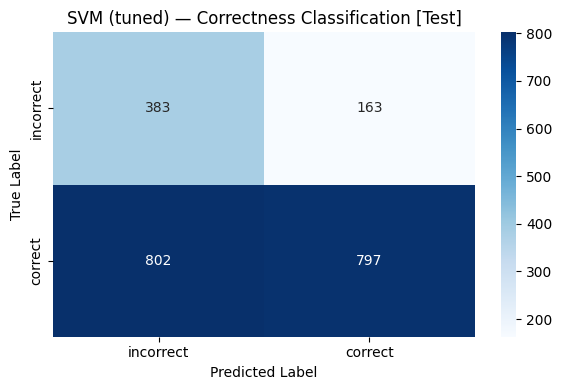

,model,task,accuracy,f1,version
1,RF,Correctness Classification,0.6625,0.6842,tuned
0,RF,Exercise Classification,0.9538,0.9537,tuned
1,Random Forest,Correctness Classification,0.6629,0.6845,baseline
0,Random Forest,Exercise Classification,0.9548,0.9547,baseline
3,SVM,Correctness Classification,0.6177,0.6418,baseline
3,SVM,Correctness Classification,0.5501,0.5770,tuned
2,SVM,Exercise Classification,0.9944,0.9944,baseline
2,SVM,Exercise Classification,0.9930,0.9930,tuned



💾 Tuned models saved to data/models/


In [12]:
# ── Evaluate tuned models on test set ────────────────────────
print("\n" + "="*60)
print("  TUNED MODEL RESULTS — TEST SET")
print("="*60)

tuned_results = []

for model, X, y, label_map, model_name, task_name in [
    (rf_ex_tuned,   X_test, y_ex_test,  EXERCISE_NAMES,    "RF (tuned)",  "Exercise Classification"),
    (rf_cor_tuned,  X_test, y_cor_test, CORRECTNESS_NAMES, "RF (tuned)",  "Correctness Classification"),
    (svm_ex_tuned,  X_test, y_ex_test,  EXERCISE_NAMES,    "SVM (tuned)", "Exercise Classification"),
    (svm_cor_tuned, X_test, y_cor_test, CORRECTNESS_NAMES, "SVM (tuned)", "Correctness Classification"),
]:
    tuned_results.append(evaluate_model(
        model=model, X=X, y=y, label_map=label_map,
        model_name=model_name, task_name=task_name, split_name="Test"
    ))

# ── Comparison table: baseline vs tuned ───────────────────────
MODELS_DIR / "model_comparison.csv"
baseline = pd.read_csv(MODELS_DIR / "model_comparison.csv")
baseline["version"] = "baseline"

tuned_df = pd.DataFrame(tuned_results)[["model", "task", "accuracy", "f1"]]
tuned_df["model"]   = tuned_df["model"].str.replace(" (tuned)", "", regex=False)
tuned_df["version"] = "tuned"
tuned_df["accuracy"] = tuned_df["accuracy"].round(4)
tuned_df["f1"]       = tuned_df["f1"].round(4)

comparison = pd.concat([baseline, tuned_df]).sort_values(["model", "task", "version"])
print("\n")
display(comparison)

# ── Save tuned models ─────────────────────────────────────────
joblib.dump(rf_ex_tuned,   MODELS_DIR / "rf_exercise_tuned.pkl")
joblib.dump(rf_cor_tuned,  MODELS_DIR / "rf_correctness_tuned.pkl")
joblib.dump(svm_ex_tuned,  MODELS_DIR / "svm_exercise_tuned.pkl")
joblib.dump(svm_cor_tuned, MODELS_DIR / "svm_correctness_tuned.pkl")
print("\n💾 Tuned models saved to data/models/")